# Spaceship Titanic
## Predict which passengers are transported to an alternate dimension

Bienvenidos al año 2912, donde sus habilidades en ciencia de datos son necesarias para resolver un misterio cósmico. Hemos recibido una transmisión desde cuatro años luz de distancia y la situación no pinta bien.

La nave espacial Titanic era un transatlántico interestelar de pasajeros que fue botado hace un mes. Con casi 13.000 pasajeros a bordo, la nave emprendió su viaje inaugural transportando emigrantes de nuestro sistema solar a tres exoplanetas recientemente habitables que orbitan estrellas cercanas.

Mientras rodeaba Alfa Centauri rumbo a su primer destino —el tórrido 55 Cancri E—, la desprevenida nave espacial Titanic colisionó con una anomalía espaciotemporal oculta en una nube de polvo. Lamentablemente, corrió la misma suerte que su homónima de 1000 años atrás. Aunque la nave permaneció intacta, ¡casi la mitad de los pasajeros fueron transportados a una dimensión alternativa!

Para ayudar a los equipos de rescate y recuperar a los pasajeros desaparecidos, tu reto consiste en predecir qué pasajeros fueron transportados por la anomalía utilizando los registros recuperados del sistema informático dañado de la nave espacial.

¡Ayúdanos a salvarlos y a cambiar la historia!

**PassengerId-** Un ID único para cada pasajero. Cada ID tiene el formato gggg_ppdonde ggggindica el grupo con el que viaja el pasajero y ppes su número dentro del grupo. Las personas en un grupo suelen ser miembros de la misma familia, pero no siempre.

**HomePlanet-** El planeta del que partió el pasajero, normalmente su planeta de residencia permanente.

**CryoSleep-** Indica si el pasajero optó por entrar en animación suspendida durante el viaje. Los pasajeros en criosueño permanecen confinados en sus camarotes.

**Cabin-** El número de camarote donde se aloja el pasajero. Tiene el formato deck/num/side, donde sidepuede ser Ppara babor o Spara estribor.

**Destination-** El planeta al que desembarcará el pasajero.

**Age-** La edad del pasajero.

**VIP-** Si el pasajero pagó por un servicio VIP especial durante el viaje.

**RoomService, FoodCourt, ShoppingMall, Spa, VRDeck-** Cantidad que el pasajero ha facturado en cada una de las numerosas comodidades de lujo del Spaceship Titanic.

**Name-** El nombre y apellido del pasajero.

**Transported-** Si el pasajero fue transportado a otra dimensión. Este es el objetivo, la columna que intentas predecir.

---

### Comienzo importando librerías y cargando el dataset

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# cargo el archivo CSV en un DataFrame de pandas llamado 'df'
df = pd.read_csv('space_titanic.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 1.2+ MB


In [4]:
df.describe()   

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [5]:
df.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [6]:
# muestro los nulos de cada variable
print("\nNulos por columna:")
print(df.isnull().sum())


Nulos por columna:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


In [7]:
# compruebo si hay duplicados
print("\nFilas Duplicadas:")
print(df.duplicated().sum())


Filas Duplicadas:
0


---
### Ingeniería de variables:

La columna 'Cabin' tiene tres valores, que parece que podrían descomponerse en cubierta, número y lado. La convierto en tres nuevas columnas a través de la división del string. Además, elimino la columna original y convierto el número de cabina en float.

In [8]:
# separo la columna 'Cabin' en tres nuevas variables: cubierta, número y lado
df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)

# elimino la columna original
df = df.drop(columns=['Cabin'])

# convierto la columna de número de cabina a tipo numérico
df['Cabin_Num'] = pd.to_numeric(df['Cabin_Num'])

# reviso cómo han quedado mis nuevas columnas
df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']].head()

,Cabin_Deck,Cabin_Num,Cabin_Side
0,B,0.0,P
1,F,0.0,S
2,A,0.0,S
3,A,0.0,S
4,F,1.0,S


---
### Trabajo con valores nulos

Identifico qué columnas son numéricas, en una lista, y relleno nulos con la mediana. En el caso de las variables categóricas, lo hago con la moda, es decir, con el valor más repetido. La columna nombre de pasajero la quito, ya que no parece que aporte en la predicción. Y, por último, compruebo si quedan valores nulos.

In [9]:
# identifico las columnas numéricas para rellenarlas con su mediana
columnas_numericas = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_Num']

for col in columnas_numericas:
    mediana = df[col].median() # calculo la mediana de la columna
    df[col] = df[col].fillna(mediana) # relleno los nulos

# identifico las columnas categóricas para rellenarlas con su moda
columnas_categoricas = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side']

for col in columnas_categoricas:
    moda = df[col].mode()[0] # calculo la moda y elijo el primer resultado
    df[col] = df[col].fillna(moda) # relleno los NaN

# elimino la columna del nombre del pasajero 
df = df.drop(columns=['Name'])

# compruebo que ya no me queda ningún valor nulo
df.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Cabin_Deck      0
Cabin_Num       0
Cabin_Side      0
dtype: int64

---
### Transformación de variables categóricas en numéricas:

Convierto las variables de True/False en 1/0. Uso el one hot encoding para las variables con varias clases. Compruebo cómo han quedado los registros después del procesado.

In [10]:
# convierto las variables de verdadero/falso a unos y ceros numéricos
columnas_booleanas = ['CryoSleep', 'VIP']
for col in columnas_booleanas:
    df[col] = df[col].astype(int) # cambio el tipo a entero

# selecciono las columnas con texto que tienen varias clases
columnas_categoricas = ['HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side']

# one hot encoding de las columnas categóricas
df = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# la columna objetivo 'Transported' también se convierte a 1 y 0, pero como no es variable predictora lo hago aparte
df['Transported'] = df['Transported'].astype(int)

# veo las primeras filas para comprobar que todo el dataset es numérico
df.head()

,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_T,Cabin_Side_S
0,0001_01,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,...,False,True,True,False,False,False,False,False,False,False
1,0002_01,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,...,False,True,False,False,False,False,True,False,False,True
2,0003_01,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,...,False,True,False,False,False,False,False,False,False,True
3,0003_02,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,...,False,True,False,False,False,False,False,False,False,True
4,0004_01,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,...,False,True,False,False,False,False,True,False,False,True


---
### Divido los datos en entrenamiento y test

In [11]:
# dataframe de variables predictoras (todas menos 'PassengerId' y la target)
x = df.drop(columns=['PassengerId', 'Transported'])

# target
y = df['Transported']

# divido los bloques en un 80% para entrenamiento y un 20% para la evaluación
# fijo una semilla
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=11)

# imprimo el tamaño de los bloques para comprobar que se han dividido bien
print(f"filas para que mi red entrene: {x_train.shape[0]}")
print(f"filas para examinar a mi red: {x_test.shape[0]}")

filas para que mi red entrene: 6954
filas para examinar a mi red: 1739


---
### Normalizo valores con Standard Scaler

In [19]:
scaler = StandardScaler() # creo la variable de escalado
x_train = scaler.fit_transform(x_train)  # aprende la media y desviación, y transforma train
x_test = scaler.transform(x_test)        # aplica la misma transformación a test (sin reaprender)

---
### Diseño y construcción de la red neuronal

In [20]:
# guardo el número exacto de variables predictoras que tiene mi bloque x
dimension_entrada = x_train.shape[1]

# configuro mi red guardando todas las capas ordenadas dentro de una lista
modelo_red = keras.Sequential([
    # defino el tamaño de la entrada usando el número de columnas de mi x_train
    keras.Input(shape=(x_train.shape[1],)),
    
    # añado mi primera capa oculta con 32 neuronas y la función de activación relu
    layers.Dense(32, activation='relu'),
    
    # añado una segunda capa oculta con 16 neuronas para buscar relaciones complejas
    layers.Dense(16, activation='relu'),
    
    # pongo la capa de salida con una sola neurona y sigmoide para la probabilidad
    layers.Dense(1, activation='sigmoid')
])

# pido ver la estructura y el resumen de conexiones de mi red recién creada
modelo_red.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

---
### Compilación de la red neuronal

In [21]:
# configuro los parámetros
modelo_red.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

---
### Entrenamiento de la red neuronal

In [22]:
historial = modelo_red.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7007 - loss: 0.5592 - val_accuracy: 0.7838 - val_loss: 0.4477
Epoch 2/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7885 - loss: 0.4348 - val_accuracy: 0.8056 - val_loss: 0.4153
Epoch 3/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7990 - loss: 0.4145 - val_accuracy: 0.8039 - val_loss: 0.4149
Epoch 4/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8047 - loss: 0.4065 - val_accuracy: 0.8085 - val_loss: 0.4024
Epoch 5/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8046 - loss: 0.4003 - val_accuracy: 0.8091 - val_loss: 0.4033
Epoch 6/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8097 - loss: 0.3962 - val_accuracy: 0.8097 - val_loss: 0.4020
Epoch 7/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8119 - loss: 0.3923 - val_accuracy: 0.8045 - val_loss: 0.3975
Epoch 8/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8082 - loss: 0.3890 - val_accuracy: 0.

---
### Creo dos gráficos: evolución de loss y evolución de acuracy

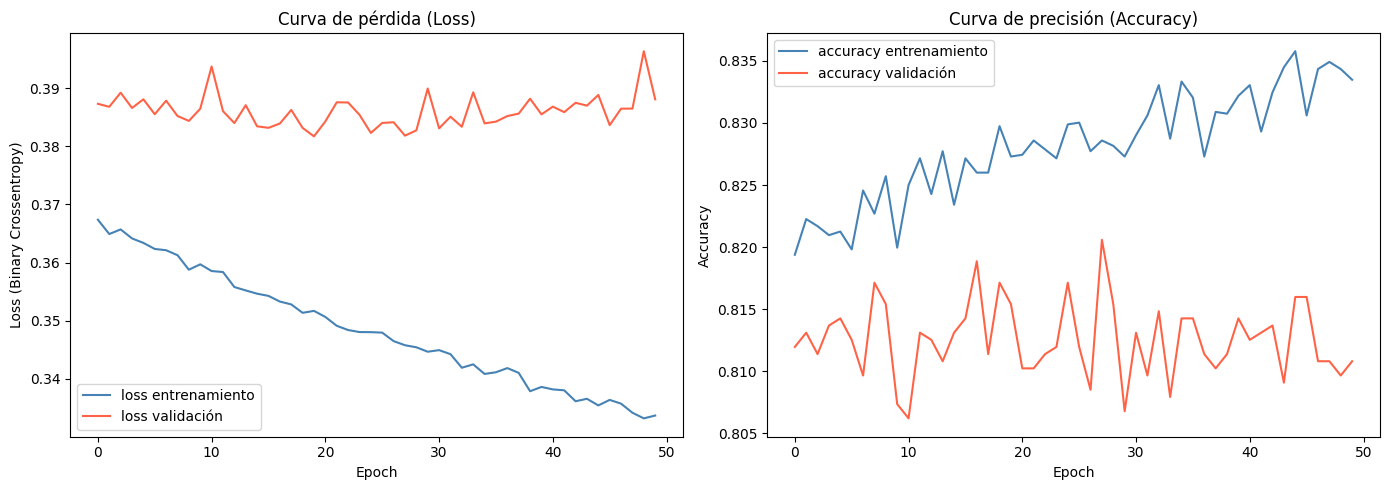

In [25]:
# creo una figura con dos gráficas en paralelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# evolución de la pérdida (loss)
ax1.plot(historial.history['loss'], label='loss entrenamiento', color='steelblue') # pérdida en train
ax1.plot(historial.history['val_loss'], label='loss validación', color='tomato') # pérdida en test
ax1.set_title('Curva de pérdida (Loss)') # título de la gráfica
ax1.set_xlabel('Epoch') # eje x: número de época
ax1.set_ylabel('Loss (Binary Crossentropy)') # eje y: valor de la pérdida
ax1.legend() # muestro la leyenda

# evolución de la precisión (accuracy)
ax2.plot(historial.history['accuracy'], label='accuracy entrenamiento', color='steelblue') # accuracy en train
ax2.plot(historial.history['val_accuracy'], label='accuracy validación', color='tomato') # accuracy en test
ax2.set_title('Curva de precisión (Accuracy)') # título de la gráfica
ax2.set_xlabel('Epoch') # eje x: número de época
ax2.set_ylabel('Accuracy') # eje y: porcentaje de aciertos
ax2.legend() # muestro la leyenda

plt.tight_layout() # ajusto el espaciado 


### Loss: las dos curvas bajan juntas y paralelas, sin separarse (sin overfitting).
### Accuracy: train en 0.82 y validación en 0.82 también (prácticamente idénticas). El modelo generaliza muy bien.

### Eso sí, ¿hacen falta más epochs?

### Yo creo que tiene sentido. Las curvas todavía tienen una pendiente suave al llegar a la epoch 20. Probaré con 50 epochs y veré si se aplanan. En ese caso, sin que la validación se despegue del train, el modelo está bien ajustado.

---


In [24]:
historial = modelo_red.fit(
    x_train, y_train,
    epochs=50, # subo de 20 a 50 para ver si las curvas se aplanan
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8194 - loss: 0.3674 - val_accuracy: 0.8120 - val_loss: 0.3873
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8223 - loss: 0.3649 - val_accuracy: 0.8131 - val_loss: 0.3868
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8217 - loss: 0.3657 - val_accuracy: 0.8114 - val_loss: 0.3892
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8210 - loss: 0.3641 - val_accuracy: 0.8137 - val_loss: 0.3866
Epoch 5/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8213 - loss: 0.3634 - val_accuracy: 0.8143 - val_loss: 0.3881
Epoch 6/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8198 - loss: 0.3623 - val_accuracy: 0.8125 - val_loss: 0.3855
Epoch 7/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8246 - loss: 0.3621 - val_accuracy: 0.8097 - val_loss: 0.3878
Epoch 8/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8227 - loss: 0.3613 - val_accuracy: 0.

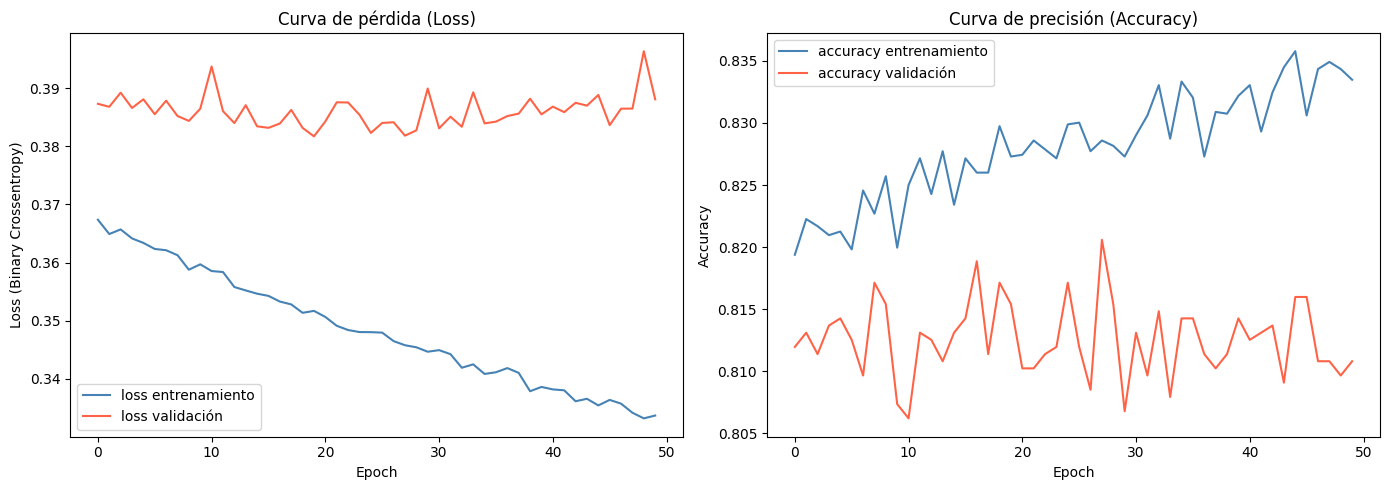

In [26]:
# creo una figura con dos gráficas en paralelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# evolución de la pérdida (loss)
ax1.plot(historial.history['loss'], label='loss entrenamiento', color='steelblue') # pérdida en train
ax1.plot(historial.history['val_loss'], label='loss validación', color='tomato') # pérdida en test
ax1.set_title('Curva de pérdida (Loss)') # título de la gráfica
ax1.set_xlabel('Epoch') # eje x: número de época
ax1.set_ylabel('Loss (Binary Crossentropy)') # eje y: valor de la pérdida
ax1.legend() # muestro la leyenda

# evolución de la precisión (accuracy)
ax2.plot(historial.history['accuracy'], label='accuracy entrenamiento', color='steelblue') # accuracy en train
ax2.plot(historial.history['val_accuracy'], label='accuracy validación', color='tomato') # accuracy en test
ax2.set_title('Curva de precisión (Accuracy)') # título de la gráfica
ax2.set_xlabel('Epoch') # eje x: número de época
ax2.set_ylabel('Accuracy') # eje y: porcentaje de aciertos
ax2.legend() # muestro la leyenda

plt.tight_layout() # ajusto el espaciado 


---
### Aquí ya se ve overfitting. Hay que parar. Parece que el train sigue bajando, pero la validación se ha quedado estancada desde la epoch 5. Las dos líneas se separan cada vez más, con lo que el modelo está memorizando el train en lugar de generalizar.

### El siguiente paso podría ser añadir dropout entre las capas ocultas para regularizar y que el modelo no se sobreajuste al entrenar más epochs. 


In [27]:
# nuevo modelo
modelo_red_v2 = keras.Sequential([
    keras.Input(shape=(dimension_entrada,)),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),  # apaga el 30% de las neuronas
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),  # apaga el 20% en la segunda capa
    
    layers.Dense(1, activation='sigmoid')
])

modelo_red_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# compilo el nuevo modelo
modelo_red_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
# entreno la v2 con 50 epochs para ver si se arregla el overfitting
historial_v2 = modelo_red_v2.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6460 - loss: 0.6339 - val_accuracy: 0.7746 - val_loss: 0.4918
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7378 - loss: 0.5230 - val_accuracy: 0.7913 - val_loss: 0.4455
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7634 - loss: 0.4905 - val_accuracy: 0.7884 - val_loss: 0.4280
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7663 - loss: 0.4722 - val_accuracy: 0.7959 - val_loss: 0.4234
Epoch 5/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7762 - loss: 0.4565 - val_accuracy: 0.8074 - val_loss: 0.4183
Epoch 6/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7765 - loss: 0.4517 - val_accuracy: 0.8085 - val_loss: 0.4143
Epoch 7/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7847 - loss: 0.4459 - val_accuracy: 0.8068 - val_loss: 0.4145
Epoch 8/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7896 - loss: 0.4327 - val_accuracy: 0.

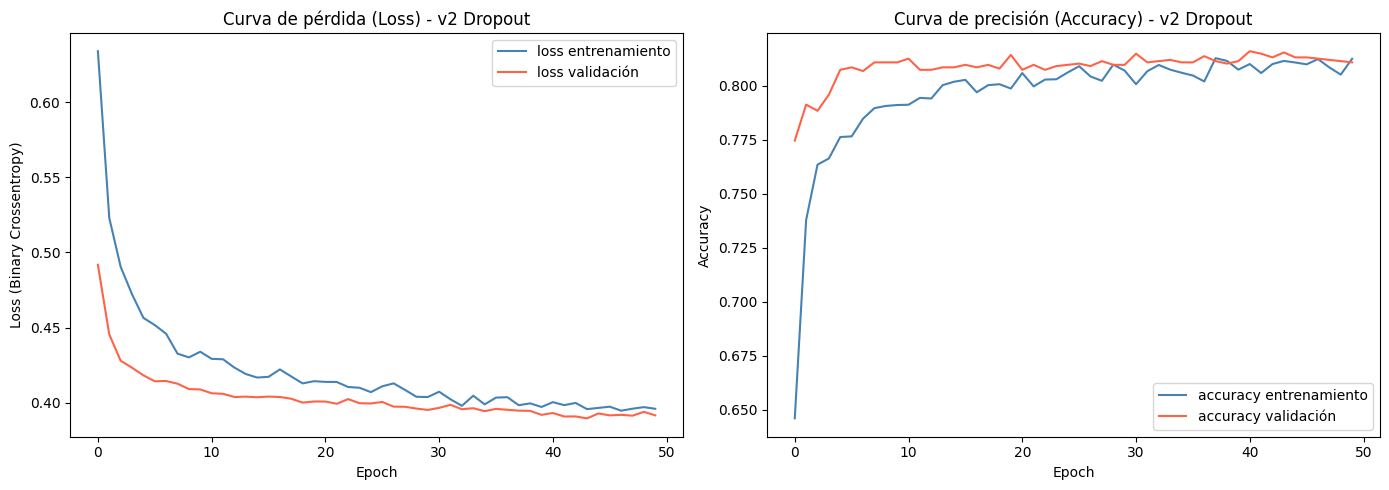

In [31]:
# visualizo las curvas de entrenamiento de la segunda versión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(historial_v2.history['loss'], label='loss entrenamiento', color='steelblue')
ax1.plot(historial_v2.history['val_loss'], label='loss validación', color='tomato')
ax1.set_title('Curva de pérdida (Loss) - v2 Dropout')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (Binary Crossentropy)')
ax1.legend()

ax2.plot(historial_v2.history['accuracy'], label='accuracy entrenamiento', color='steelblue')
ax2.plot(historial_v2.history['val_accuracy'], label='accuracy validación', color='tomato')
ax2.set_title('Curva de precisión (Accuracy) - v2 Dropout')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

### Parece que el dropout ha funcionado bien.

### Loss: las dos curvas bajan juntas y convergen en alrededor de 0.40. Sin overfitting.
### Accuracy: las dos líneas van prácticamente pegadas y se aplanan suavemente a partir de la epoch 30, ambas en 0.80. 

---


In [34]:
# evalúo el modelo_red_v2 con los datos de test
perdida_test, accuracy_test = modelo_red_v2.evaluate(x_test, y_test, verbose=0)
print(f"\nResultados sobre el conjunto de test:")
print(f"  Loss:     {perdida_test:.4f}")
print(f"  Accuracy: {accuracy_test:.4f}")

# genero las predicciones en probabilidades
y_pred_prob = modelo_red_v2.predict(x_test)

# convierto probabilidades a etiquetas binarias con umbral 0.5
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# informe completo de clasificación
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No transportado', 'Transportado']))


Resultados sobre el conjunto de test:
  Loss:     0.3917
  Accuracy: 0.8108
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step

Informe de clasificación:
                 precision    recall  f1-score   support

No transportado       0.79      0.81      0.80       820
   Transportado       0.83      0.81      0.82       919

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



### Accuracy de 0.81: el modelo acierta 8 de cada 10 pasajeros.
### Precision, recall y F1 equilibrados en ambas clases: no hay sesgo hacia ninguna clase.

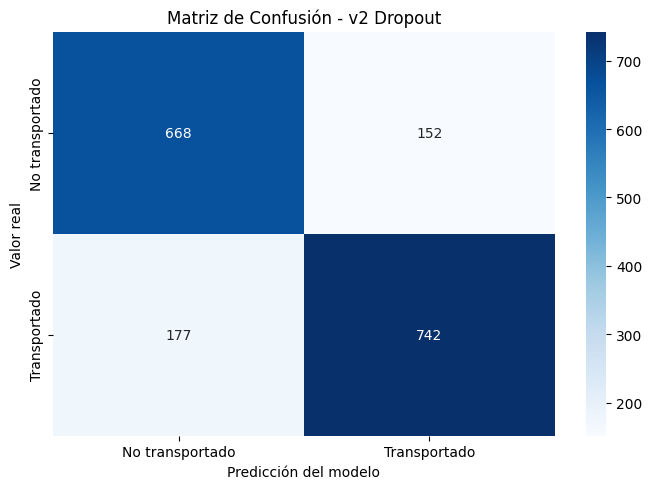

In [37]:
# matriz de confusión del modelo v2
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No transportado', 'Transportado'],
    yticklabels=['No transportado', 'Transportado']
)
plt.title('Matriz de Confusión - v2 Dropout')
plt.ylabel('Valor real')
plt.xlabel('Predicción del modelo')
plt.tight_layout()
plt.show()

### El modelo acierta 668 no transportados y 742 transportados.
### Se equivoca en 152 falsos positivos (predice transportado pero no lo estaba).
### Se equivoca en 177 falsos negativos (predice no transportado pero sí lo estaba).

---

### He descargado el test de Kaggle para realizar predicciones

In [41]:
# cargo el test de Kaggle
df_kaggle = pd.read_csv('test.csv')

# reviso su estructura
df_kaggle.info()

<class 'pandas.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   str    
 1   HomePlanet    4190 non-null   str    
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   str    
 4   Destination   4185 non-null   str    
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   str    
dtypes: float64(6), object(2), str(5)
memory usage: 617.2+ KB


In [42]:
# guardo el PassengerId para el archivo de entrega
passenger_ids = df_kaggle['PassengerId']

# separo Cabin en tres columnas
df_kaggle[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df_kaggle['Cabin'].str.split('/', expand=True)
df_kaggle = df_kaggle.drop(columns=['Cabin'])
df_kaggle['Cabin_Num'] = pd.to_numeric(df_kaggle['Cabin_Num'])

# relleno nulos numéricos con la mediana
for col in columnas_numericas:
    df_kaggle[col] = df_kaggle[col].fillna(df_kaggle[col].median())

# relleno nulos categóricos con la moda
for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side']:
    df_kaggle[col] = df_kaggle[col].fillna(df_kaggle[col].mode()[0])

# elimino Name
df_kaggle = df_kaggle.drop(columns=['Name'])

# convierto booleanas a enteros
for col in columnas_booleanas:
    df_kaggle[col] = df_kaggle[col].astype(int)

# one hot encoding
df_kaggle = pd.get_dummies(df_kaggle, columns=['HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side'], drop_first=True)

# alinea las columnas del test con las de x_train por si hay diferencias
x_kaggle = df_kaggle.drop(columns=['PassengerId'])
x_kaggle = x_kaggle.reindex(columns=x.columns, fill_value=0)

# normalizo con el scaler ya entrenado en train
x_kaggle_scaled = scaler.transform(x_kaggle)

# genero las predicciones
y_kaggle_prob = modelo_red_v2.predict(x_kaggle_scaled)
y_kaggle = (y_kaggle_prob >= 0.5).flatten()

# creo el CSV de entrega
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Transported': y_kaggle
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print(f"\ntotal predicciones: {len(submission)}")

134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step
  PassengerId  Transported
0     0013_01        False
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01        False
5     0027_01         True
6     0029_01         True
7     0032_01         True
8     0032_02         True
9     0033_01         True

total predicciones: 4277


--- 
Entonces, ¿cuántos pasajeros han sido transportados a otra dimensión?

In [49]:
# recargo el test original para recuperar los nombres
df_nombres = pd.read_csv('test.csv')[['PassengerId', 'Name']]

# uno los nombres con las predicciones
submission_con_nombres = submission.merge(df_nombres, on='PassengerId', how='left')

# creo el dataframe final con nombre en lugar de ID
submission_final = submission_con_nombres[['Name', 'Transported']]

# filtro solo los transportados
transportados = submission_final[submission_final['Transported'] == True].reset_index(drop=True)

print(f"Pasajeros transportados a la dimensión alternativa: {len(transportados)}")
transportados

Pasajeros transportados a la dimensión alternativa: 2083


,Name,Transported
0,Sabih Unhearfus,True
1,Meratz Caltilter,True
2,Karlen Ricks,True
3,Aldah Ainserfle,True
4,Acrabi Pringry,True
...,...,...
2078,Jeron Peter,True
2079,Matty Scheron,True
2080,Jayrin Pore,True
2081,Kitakan Conale,True
